In [ ]:
# L1 (Lasso Regularization) | L2 (Ridge Regularization) 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
dataset = pd.read_csv("houseprice.csv")
dataset.head(3)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,2,1.00,1180,5650,1.0,0,0,3,1180,0,1955,0,231300.0
1,3,2.25,2570,7242,2.0,0,0,3,2170,400,1951,1991,538000.0
2,2,1.00,770,10000,1.0,0,0,3,770,0,1933,0,180000.0


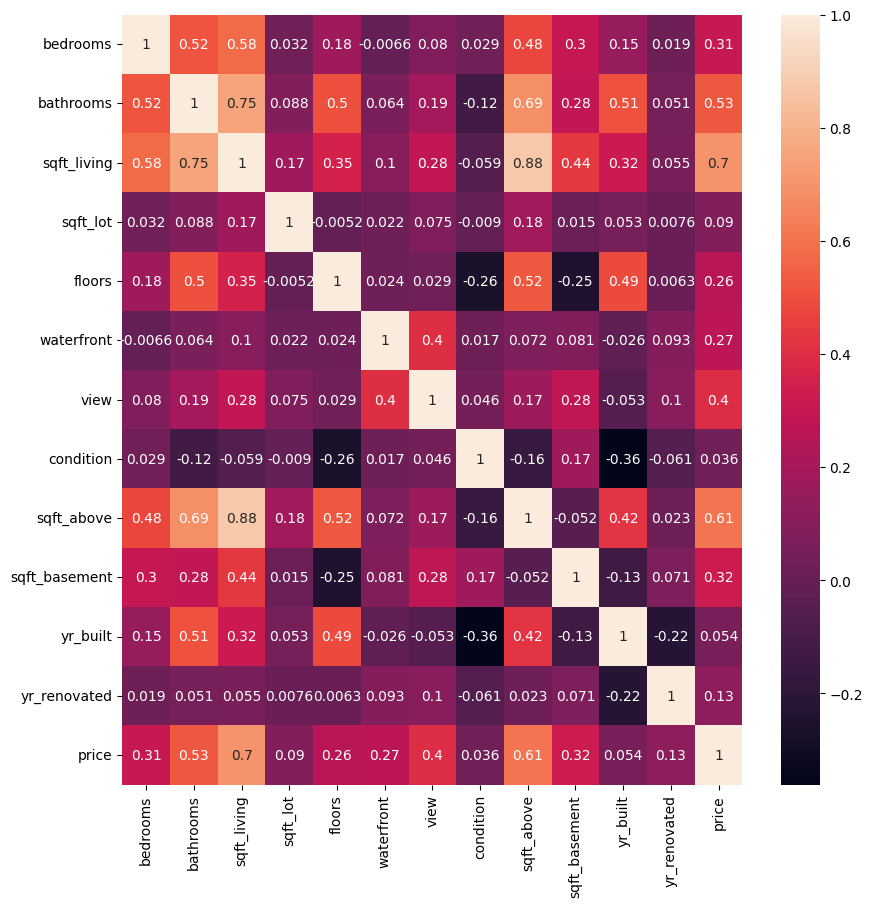

In [4]:
plt.figure(figsize=(10, 10))
sns.heatmap(data = dataset.corr(), annot=True)
plt.show()

In [6]:
x = dataset.iloc[:,:-1]
y = dataset["price"]

In [7]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns = x.columns)
x

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,-1.473841,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.734708,-0.658681,-0.544898,-0.210128
1,-0.398669,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,0.460841,0.245141,-0.681079,4.746678
2,-1.473841,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.229834,-0.658681,-1.293892,-0.210128
3,0.676503,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.891699,1.397515,-0.204446,-0.210128
4,-0.398669,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,-0.130895,-0.658681,0.544548,-0.210128
...,...,...,...,...,...,...,...,...,...,...,...,...
21608,-0.398669,0.500221,-0.598746,-0.337424,2.788439,-0.087173,-0.305759,-0.629187,-0.312039,-0.658681,1.293542,-0.210128
21609,0.676503,0.500221,0.250539,-0.224386,0.936506,-0.087173,-0.305759,-0.629187,0.629908,-0.658681,1.463768,-0.210128
21610,-1.473841,-1.772078,-1.154047,-0.332137,0.936506,-0.087173,-0.305759,-0.629187,-0.927928,-0.658681,1.293542,-0.210128
21611,-0.398669,0.500221,-0.522528,-0.307076,0.936506,-0.087173,-0.305759,-0.629187,-0.227505,-0.658681,1.123316,-0.210128


In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# LinearRegression

In [12]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)*100

59.88156528755446

In [33]:
mean_squared_error(y_test, lr.predict(x_test))

60721137799.81036

In [34]:
mean_absolute_error(y_test, lr.predict(x_test))

158388.17637459972

In [36]:
print(mean_squared_error(y_test, lr.predict(x_test)))
print(mean_absolute_error(y_test, lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

60721137799.81036
158388.17637459972
246416.5940025354


In [13]:
lr.coef_

array([-51447.92663755,  50512.03472499, 128882.64411034, -15241.31348671,
        24791.38273665,  43721.67581271,  47888.5135559 ,  10965.79756991,
       117953.19311666,  46760.69427712, -85575.26022632,   4748.03588431])

In [14]:
lr.intercept_

np.float64(539618.5720991743)

In [17]:
x.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='str')

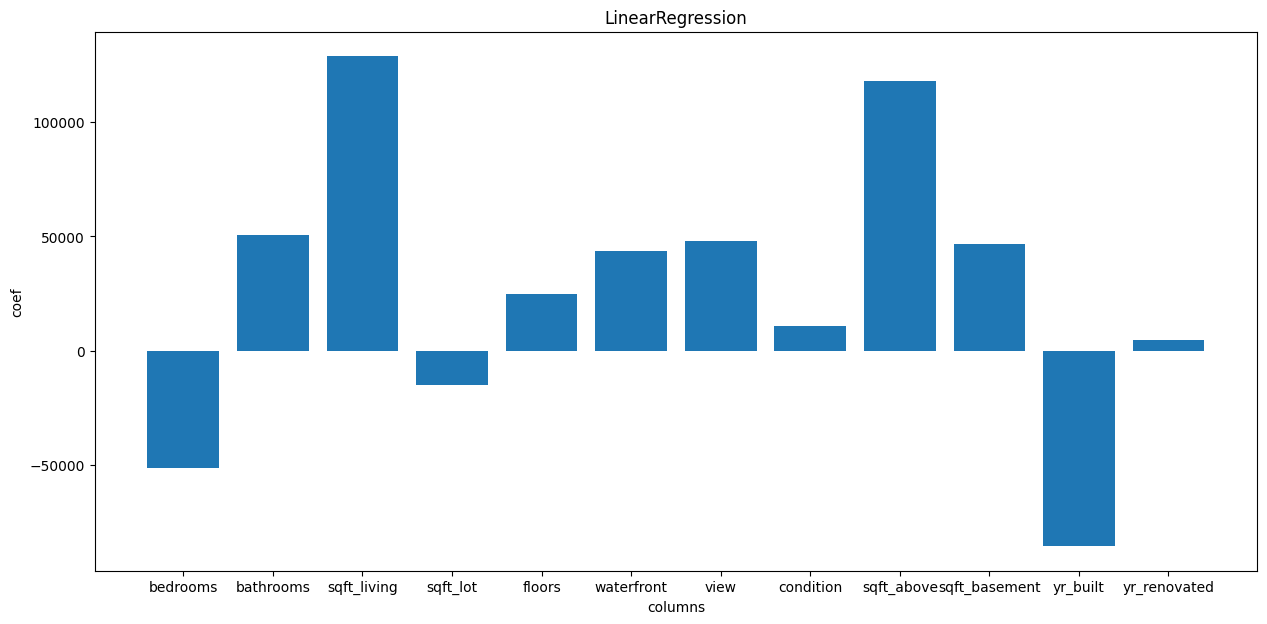

In [23]:
plt.figure(figsize=(15, 7))
plt.bar(x.columns, lr.coef_)
plt.title("LinearRegression")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

# Lasso

In [25]:
la = Lasso(alpha = 0.5)
la.fit(x_train, y_train)
la.score(x_test, y_test)*100

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.547e+13, tolerance: 2.262e+11
  model = cd_fast.enet_coordinate_descent(


59.88157639923215

In [37]:
print(mean_squared_error(y_test, la.predict(x_test)))
print(mean_absolute_error(y_test, la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, la.predict(x_test))))

60721120981.76357
158388.2043614647
246416.55987730122


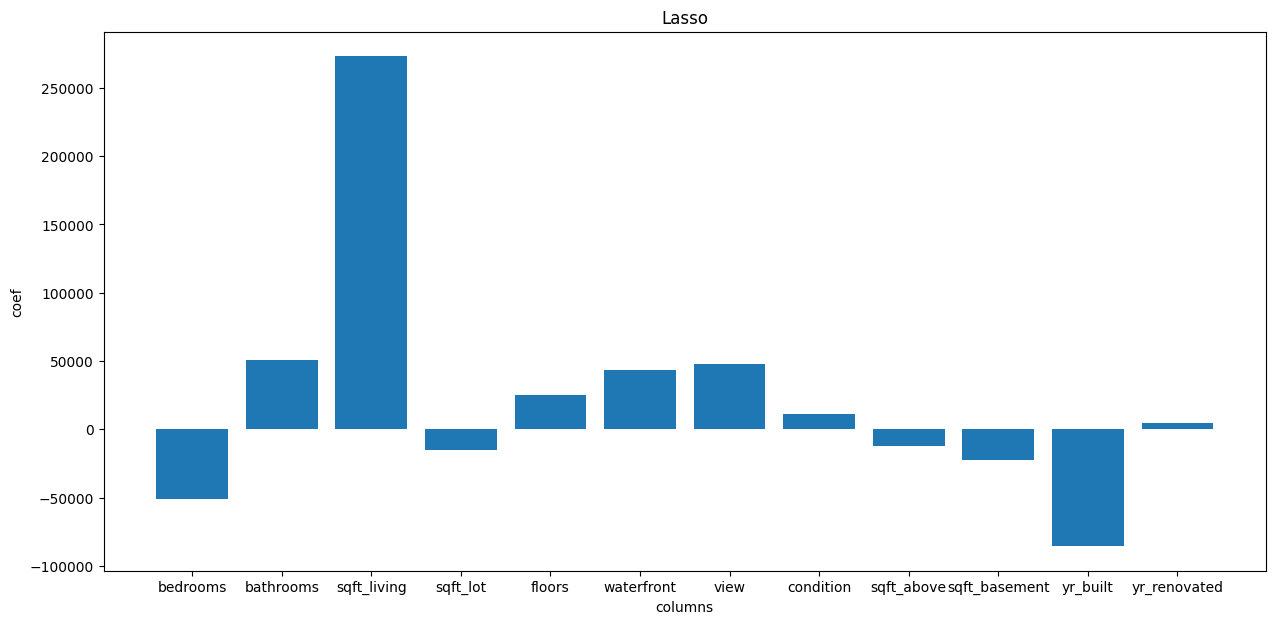

In [26]:
plt.figure(figsize=(15, 7))
plt.bar(x.columns, la.coef_)
plt.title("Lasso")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

# Ridge

In [29]:
ri = Ridge(alpha = 10)
ri.fit(x_train, y_train)
ri.score(x_test, y_test)*100

59.88114511594993

In [38]:
print(mean_squared_error(y_test, ri.predict(x_test)))
print(mean_absolute_error(y_test, ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, ri.predict(x_test))))

60721773749.295456
158375.61700303716
246417.88439416376


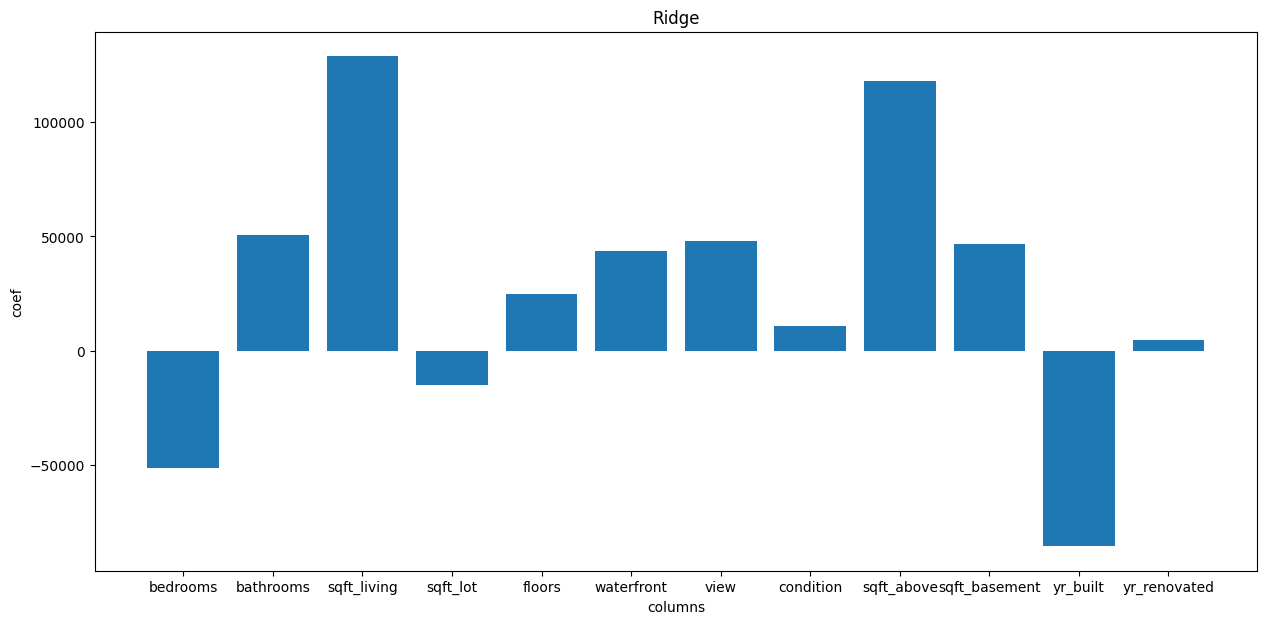

In [30]:
plt.figure(figsize=(15, 7))
plt.bar(x.columns, ri.coef_)
plt.title("Ridge")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

In [39]:
df = pd.DataFrame({"col_name": x.columns, "LinearRegression":lr.coef_, "Lasso":la.coef_, "Ridge":ri.coef_})

In [40]:
df

,col_name,LinearRegression,Lasso,Ridge
0,bedrooms,-51447.926638,-51447.301633,-51329.982304
1,bathrooms,50512.034725,50508.765797,50493.394868
2,sqft_living,128882.644110,273253.556714,128793.063618
3,sqft_lot,-15241.313487,-15240.656723,-15206.797444
4,floors,24791.382737,24791.684222,24782.247615
5,waterfront,43721.675813,43721.350924,43706.130485
6,view,47888.513556,47888.320880,47907.005781
7,condition,10965.797570,10965.255027,10980.795427
8,sqft_above,117953.193117,-12213.750534,117864.605115
9,sqft_basement,46760.694277,-22806.494432,46740.549756
